# Bots Without Labels

*Finding automated traffic in logs where nobody has told you which rows are bots.*

Most bot-detection write-ups quietly assume labelled data. Real logs almost never
come with a ground-truth `is_bot` column, so you are left detecting anomalies you
can't measure. This notebook walks the whole workflow:

1. Load **any** log and let the schema be inferred automatically.
2. Turn columns into features by their **role**.
3. Score every event with two classifiers — an explainable **rules** detector and
   an unsupervised **Extended Isolation Forest** — and pick a self-tuned threshold.
4. **Plant synthetic bots** with known signatures and *measure* recall, because the
   data has no labels of its own.

The name nods to Peter Gabriel's *Games Without Frontiers*: detection with no
labels to keep score by — so we plant our own.

In [1]:
from pathlib import Path
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bots_without_labels import synthetic, evaluate
from bots_without_labels.ingest import load
from bots_without_labels.features import build_features
from bots_without_labels.inject import inject_bots
from bots_without_labels.pipeline import detect, HEURISTIC_CUTOFF

pd.set_option("display.max_columns", 30)

## 1. A log to analyse

The detector works on any CSV/TSV/JSON log. Here we *generate* one, because a
generated log comes with planted ground truth — which is what lets us measure
recall later. To analyse your own data instead, just point `load(...)` at a file.

In [2]:
log = synthetic.generate(n_legit=1500, n_bots=90, seed=7)
workdir = Path(tempfile.mkdtemp())
synthetic.write_log(workdir / "log.tsv", log.frame)

loaded = load(workdir / "log.tsv")          # <-- swap for load("your-log.csv")
print(loaded.schema.describe())

1590 rows, format=tsv  (timestamp=event_time; row_id=event_id; urls=url)
  event_id    identifier   unique=1590 missing=0
  event_time  timestamp    unique=1558 missing=0
  region      categorical  unique=10 missing=0
  browser     categorical  unique=4 missing=0
  os          categorical  unique=5 missing=0
  url         url          unique=1504 missing=0
  url__path   categorical  unique=1 missing=0 <- url
  url__d      categorical  unique=9 missing=0 <- url
  url__q      text         unique=1400 missing=0 <- url
  url__ttc    numeric      unique=1380 missing=0 <- url
  url__ct     categorical  unique=10 missing=0 <- url


## 2. The schema, inferred

Nothing about the columns was declared. The loader sniffed the format, classified
every column's **role**, found the timestamp and the row id, and expanded the
URL's query string (`url__d`, `url__q`, `url__ttc`, ...) into ordinary columns.

In [3]:
pd.DataFrame([c.to_dict() for c in loaded.schema.columns])[
    ["name", "role", "n_unique", "n_missing", "derived_from"]
]

,name,role,n_unique,n_missing,derived_from
0,event_id,identifier,1590,0,NaN
1,event_time,timestamp,1558,0,NaN
2,region,categorical,10,0,NaN
3,browser,categorical,4,0,NaN
4,os,categorical,5,0,NaN
5,url,url,1504,0,NaN
6,url__path,categorical,1,0,url
7,url__d,categorical,9,0,url
8,url__q,text,1400,0,url
9,url__ttc,numeric,1380,0,url


## 3. Features, derived from roles

Each role produces its own features: categorical columns become *concentration*,
numbers become a *value* plus *exact-reuse* count, free text becomes *entropy*,
*character diversity* and *repetition*, and the timestamp becomes *hour*,
*same-instant* and *local-burst* density, and *inter-arrival regularity*. The
click-specific signals are just what this schema happens to produce.

In [4]:
features = build_features(loaded.frame, loaded.schema)
print(f"{len(features.names)} features derived")
features.frame().head()

17 features derived


,region__conc,browser__conc,os__conc,url__path__conc,url__d__conc,url__ct__conc,context__conc,url__ttc__val,url__ttc__rep,url__q__entropy,url__q__uniqchar,url__q__rep,hour,same_time__conc,burst10s__conc,dt__std,dt__cv
0,5.068904,6.013715,5.697093,7.372118,5.733341,5.049856,1.098612,4814.0,1.098612,3.251629,0.833333,0.693147,5.0,0.693147,0.693147,6.907755,6.907755
1,5.123964,5.955837,5.774552,7.372118,5.700444,5.068904,1.791759,6644.0,1.098612,3.536887,0.684211,0.693147,16.0,0.693147,0.693147,8.530805,0.406613
2,5.288267,6.013715,5.805135,7.372118,5.697093,5.278115,1.098612,4048.0,0.693147,3.559080,0.560000,0.693147,23.0,0.693147,0.693147,6.907755,6.907755
3,4.969813,5.955837,5.697093,7.372118,5.631212,4.934474,0.693147,3770.0,0.693147,3.095795,0.818182,0.693147,19.0,0.693147,0.693147,6.907755,6.907755
4,5.023881,6.023448,5.805135,7.372118,5.768321,4.976734,0.693147,1052.0,0.693147,3.188722,0.833333,1.098612,15.0,0.693147,0.693147,6.907755,6.907755


## 4. Two classifiers and a self-tuned threshold

The **rules** detector gives an explainable score; the **Extended Isolation
Forest** gives an unsupervised anomaly score. Because there are no labels, the
anomaly threshold is chosen at the *elbow* of the sorted-score curve (Kneedle),
where the steep anomaly tail gives way to the flat body of ordinary traffic.

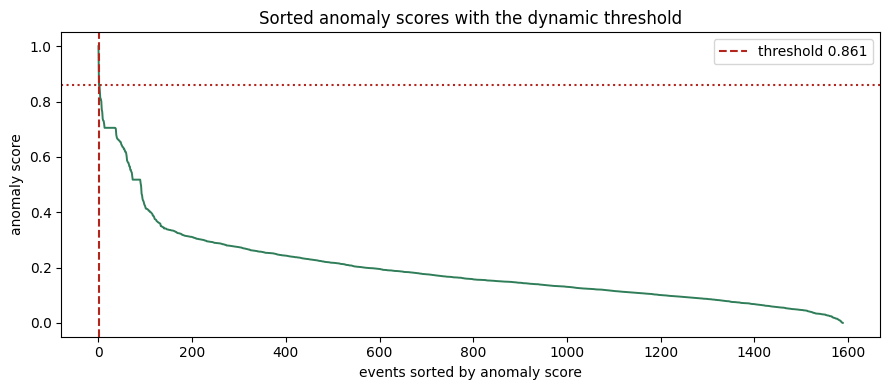

flagged 90 of 1590 events (5.7%)  -  backend: eif


In [5]:
result = detect(loaded.frame, loaded.schema)

ordered = np.sort(result.ml_scores)[::-1]
cut = result.ml_threshold
idx = int((ordered > cut).sum())

plt.figure(figsize=(9, 4))
plt.plot(ordered, color="#2f7d59", lw=1.4)
plt.axvline(idx, ls="--", c="#b3261e", label=f"threshold {cut:.3f}")
plt.axhline(cut, ls=":", c="#b3261e")
plt.title("Sorted anomaly scores with the dynamic threshold")
plt.xlabel("events sorted by anomaly score"); plt.ylabel("anomaly score")
plt.legend(); plt.tight_layout(); plt.show()

print(f"flagged {int(result.is_bot.sum())} of {len(result.is_bot)} events "
      f"({result.is_bot.mean():.1%})  -  backend: {result.ml_backend}")

## 5. The payoff — measuring recall with planted labels

This is the whole point. Because *we* planted the bots, we know the answer key,
so the detector's output can be scored honestly — overall and per archetype.
Precision here is measured only against the planted set, so it is a lower bound:
real traffic may contain genuine bots the detector also (correctly) flags.

recall: 100%    planted-precision: 100%    (recovered 90 of 90 planted)


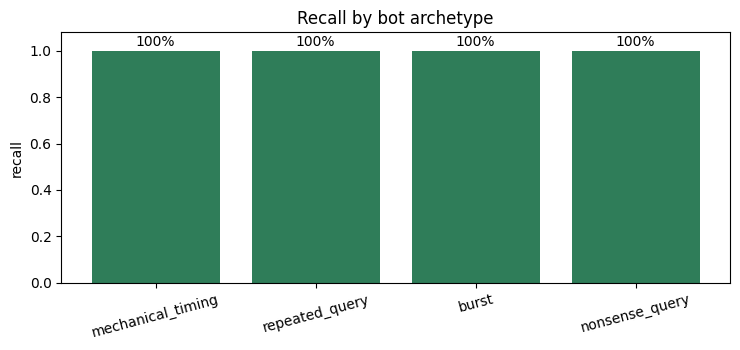

In [6]:
report = evaluate.evaluate_injection(result.is_bot, log.is_bot, log.archetype)
print(f"recall: {report['recall']:.0%}    planted-precision: {report['planted_precision']:.0%}    "
      f"(recovered {report['recovered']} of {report['planted']} planted)")

per = report["per_archetype"]
names = list(per); recalls = [per[n]["recall"] for n in names]
plt.figure(figsize=(7.5, 3.6))
bars = plt.bar(names, recalls, color="#2f7d59")
plt.ylim(0, 1.08); plt.ylabel("recall"); plt.title("Recall by bot archetype")
plt.xticks(rotation=15)
for bar, r in zip(bars, recalls):
    plt.text(bar.get_x() + bar.get_width() / 2, r + 0.02, f"{r:.0%}", ha="center")
plt.tight_layout(); plt.show()

## 6. Why was each event flagged?

Every rule contribution carries a human-readable reason, so a reviewer can see the
evidence behind each decision rather than trusting an opaque score.

In [7]:
reasons = result.reasons()
ids = loaded.frame[loaded.schema.row_id].tolist()
flagged = sorted(
    (i for i in range(len(ids)) if result.is_bot[i]),
    key=lambda i: result.combined[i], reverse=True,
)[:8]
pd.DataFrame([
    {
        "event_id": ids[i],
        "heuristic": round(float(result.heuristic[i]), 2),
        "anomaly": round(float(result.ml_scores[i]), 2),
        "why": ", ".join(reasons[i][:3]),
    }
    for i in flagged
])

,event_id,heuristic,anomaly,why
0,m1560,1.0,0.52,"url__q repeated 22 times, exact url__ttc value..."
1,b1516,1.0,0.70,"url__q repeated 23 times, exact url__ttc value..."
2,m1565,1.0,0.52,"url__q repeated 22 times, exact url__ttc value..."
3,m1561,1.0,0.52,"url__q repeated 22 times, exact url__ttc value..."
4,b1521,1.0,0.70,"url__q repeated 23 times, exact url__ttc value..."
5,b1504,1.0,0.70,"url__q repeated 23 times, exact url__ttc value..."
6,b1522,1.0,0.70,"url__q repeated 23 times, exact url__ttc value..."
7,b1502,1.0,0.70,"url__q repeated 23 times, exact url__ttc value..."


## 7. Works on any log — inject bots into your own data

The same idea generalises beyond click logs. Given *any* loaded log, `inject_bots`
synthesises bot rows from the detected roles, so you can measure recall on traffic
that has no labels of its own. Here is a completely different schema
(`user, ts, action, latency_ms, message`). How much is recoverable depends on
which signals the log exposes — a log with a free-text field and timestamps gives
the archetypes more to work with.

In [8]:
rng = np.random.default_rng(0)
words = ["alpha", "bravo", "charlie", "delta", "echo", "foxtrot", "golf",
         "hotel", "india", "juliet", "kilo", "lima", "mike", "november"]
lines = ["user,ts,action,latency_ms,message"]
for i in range(800):
    msg = " ".join(rng.choice(words, size=3))
    lines.append(f"u{i},2023-03-{1 + i % 27:02d} {i % 24:02d}:{i % 60:02d}:00,"
                 f"act{rng.integers(0, 30)},{rng.integers(20, 900)},{msg}")
generic_path = Path(tempfile.mkdtemp()) / "events.csv"
generic_path.write_text("\n".join(lines))

generic = load(generic_path)
injected = inject_bots(generic.frame, generic.schema, n_bots=60, seed=2)
generic_result = detect(injected.frame, generic.schema)
generic_report = evaluate.evaluate_injection(
    generic_result.is_bot, injected.is_injected, injected.archetype
)
print(generic.schema.describe().splitlines()[0])
print(f"recall on planted bots: {generic_report['recall']:.0%}    "
      f"planted-precision: {generic_report['planted_precision']:.0%}")

800 rows, format=csv  (timestamp=ts; row_id=user)
recall on planted bots: 100%    planted-precision: 100%


## 8. Honest limits

The planted bots are, by construction, detectable: they burst, repeat, reuse exact
values, or click on a metronome. That is exactly why we can *measure* on them. The
genuinely hard case — a bot that mimics human variance and never repeats — leaves
no signature and cannot be measured without real labels. The value here is the
**workflow**: load anything, detect with explanations, and turn an unlabelled
problem into a measured one by planting your own ground truth.